# PINN for 1D Heat Conduction with Internal Heat Generation and a Convective Boundary

This notebook considers steady one-dimensional heat conduction with internal heat generation,

\[ k\frac{d^2T}{dx^2}+q=0, \qquad 0\leq x\leq1. \]

The boundary conditions are

\[ T(0)=0 \]

and

\[ -k\frac{dT}{dx}(1) = h[T(1)-T_\infty]. \]

The second condition is a Robin boundary condition representing convective heat loss at the right boundary.

For

\[k=q=h=1, \qquad T_\infty=0, \]

the analytical solution is

\[ T(x)=-\frac{1}{2}x^2+\frac{3}{4}x. \]

The PINN is trained by minimizing the governing-equation residual together with the Dirichlet and Robin boundary-condition residuals.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(43)

# Collocation points in the domain: 0 <= x <= 1
x_colloc = torch.linspace(0, 1, 100).view(-1, 1)

# Required because derivatives with respect to x will be calculated
x_colloc.requires_grad_(True)

# Neural Network
model = nn.Sequential(
    nn.Linear(1,32),
    nn.Tanh(),
    nn.Linear(32,32),
    nn.Tanh(),
    nn.Linear(32,1)
)

# Boundary Locations
x_left  = torch.tensor([[0.0]])
x_right = torch.tensor([[1.0]], requires_grad=True)

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

# Reduce learning rate during training
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.5
)

## PINN Training

Automatic differentiation is used to evaluate both the second derivative inside the domain and the first derivative required by the Robin boundary condition.

In [ ]:
n_epoch = 3000
k = 1       # Thermal Conductivity
q = 1       # Volumetric heat-generation term
h = 1       # Convective Coefficient
Tinf = 0    # Ambient Temperature

for epoch in range(n_epoch):
    # Forward pass: predict T(x)
    T = model(x_colloc)

    # Automatic differentiation
    dT_dx = torch.autograd.grad(
        T, x_colloc,
        grad_outputs=torch.ones_like(T),
        create_graph=True
    )[0]

    d2T_dx2 = torch.autograd.grad(
        dT_dx, x_colloc,
        grad_outputs=torch.ones_like(dT_dx),
        create_graph=True
    )[0]

    # PDE loss: k*d²T/dx² + q = 0
    pde_residual = k*d2T_dx2 + q
    loss_pde = torch.mean(pde_residual**2)

    # Boundary conditions: T(0) = 0; -k*dT/dx(1) = h*(T(1) - Tinf)
    T_left  = model(x_left)
    T_right = model(x_right)

    dT_dx_right = torch.autograd.grad(
                    T_right, x_right,
                    grad_outputs=torch.ones_like(T_right),
                    create_graph=True
                )[0]
    
    loss_left   = torch.mean((T_left - 0.0)**2)

    robin_residual = (
        k*dT_dx_right
        + h*(T_right - Tinf)
    )

    loss_right = torch.mean(robin_residual**2)

    loss_bc     = loss_left + loss_right

    loss = loss_pde + loss_bc

    # Update NN parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Display training progress
    if epoch % 300 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"PDE loss = {loss_pde.item():.6f} | "
            f"BC loss = {loss_bc.item():.6f} | "
            f"Total loss = {loss.item():.6f}"
        )

Epoch    0 | PDE loss = 0.958418 | BC loss = 0.175711 | Total loss = 1.134128
Epoch  300 | PDE loss = 0.000031 | BC loss = 0.000000 | Total loss = 0.000031
Epoch  600 | PDE loss = 0.000030 | BC loss = 0.000001 | Total loss = 0.000031
Epoch  900 | PDE loss = 0.000015 | BC loss = 0.000000 | Total loss = 0.000015
Epoch 1200 | PDE loss = 0.000009 | BC loss = 0.000000 | Total loss = 0.000009
Epoch 1500 | PDE loss = 0.000006 | BC loss = 0.000000 | Total loss = 0.000006
Epoch 1800 | PDE loss = 0.000004 | BC loss = 0.000000 | Total loss = 0.000004
Epoch 2100 | PDE loss = 0.000003 | BC loss = 0.000000 | Total loss = 0.000003
Epoch 2400 | PDE loss = 0.000002 | BC loss = 0.000000 | Total loss = 0.000002
Epoch 2700 | PDE loss = 0.000001 | BC loss = 0.000000 | Total loss = 0.000001


## Evaluation

The trained PINN is compared with the analytical solution at selected points.

In [3]:
x_check = torch.linspace(0,1,5).view(-1,1)

model.eval()
with torch.no_grad():
    T_pred = model(x_check)

print("\nPINN vs analytical solution\n")
for i in range(len(x_check)):
    x_val       = x_check[i].item()
    pinn_val    = T_pred[i].item()
    exact_val   = (-(0.5*x_val**2)+(0.75*x_val))

    print(
        f"x     = {x_val:.2f} | "
        f"PINN  = {pinn_val:.4f} | "
        f"Exact = {exact_val:.4f}"
    )


PINN vs analytical solution

x     = 0.00 | PINN  = 0.0000 | Exact = 0.0000
x     = 0.25 | PINN  = 0.1563 | Exact = 0.1562
x     = 0.50 | PINN  = 0.2500 | Exact = 0.2500
x     = 0.75 | PINN  = 0.2813 | Exact = 0.2812
x     = 1.00 | PINN  = 0.2500 | Exact = 0.2500


## Solution Comparison

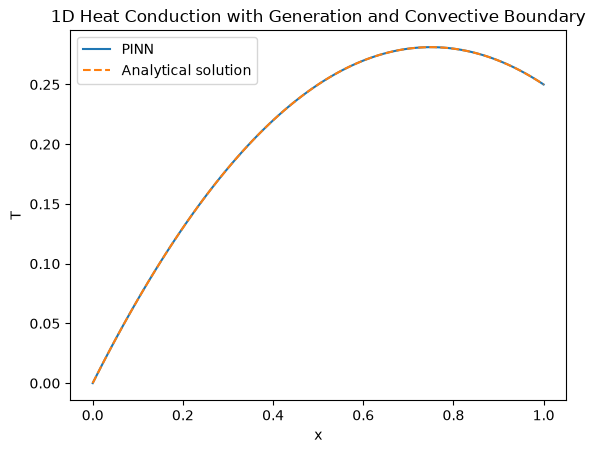

In [4]:
x_plot = torch.linspace(0, 1, 100).view(-1, 1)
with torch.no_grad():
    T_pinn = model(x_plot)


T_exact = (-(0.5*x_plot**2)+(0.75*x_plot))

plt.plot(
    x_plot.numpy(),
    T_pinn.numpy(),
    label="PINN"
)

plt.plot(
    x_plot.numpy(),
    T_exact.numpy(),
    "--",
    label="Analytical solution"
)

plt.title("1D Heat Conduction with Generation and Convective Boundary")
plt.xlabel("x")
plt.ylabel("T")
plt.legend()
plt.show()